# Stage 2 — FinanceBench Dataset Audit

This notebook audits the **local Stage 1 snapshot** before any RAG architecture is built.

Objectives:

- verify shape, columns and identifier integrity;
- inspect FinanceBench's native `question_type` categories;
- inspect FinanceBench's native `question_reasoning` categories;
- measure company and document coverage;
- inspect gold `evidence` objects;
- preserve the distinction between benchmark-provided categories and any later hypothesis-specific labels;
- write `data/processed/dataset_summary.json` using measured values rather than hard-coded counts.

**Do not create custom numeric/terminology flags in this notebook.** First understand the benchmark labels and evidence.


In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
import matplotlib.pyplot as plt

CWD = Path.cwd().resolve()
ROOT = CWD.parent if CWD.name == "notebooks" else CWD

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data.financebench_loader import (
    EXPECTED_OPEN_SOURCE_ROWS,
    build_unique_document_table,
    load_local_financebench,
)

SNAPSHOT_PATH = ROOT / "data" / "raw" / "financebench" / "questions.jsonl"
SUMMARY_PATH = ROOT / "data" / "processed" / "dataset_summary.json"

print("Repository root:", ROOT)
print("Snapshot:", SNAPSHOT_PATH)


C:\Users\dell 5590 i7\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Repository root: C:\Users\dell 5590 i7\Documents\GITHUB\finrag-arch-eval
Snapshot: C:\Users\dell 5590 i7\Documents\GITHUB\finrag-arch-eval\data\raw\financebench\questions.jsonl


## 1. Load the local Stage 1 snapshot


In [4]:
df = load_local_financebench(SNAPSHOT_PATH)
print(f"Loaded rows: {len(df)}")
assert len(df) == EXPECTED_OPEN_SOURCE_ROWS, (
    f"Expected {EXPECTED_OPEN_SOURCE_ROWS} rows, got {len(df)}."
)
df.head(3)


Loaded rows: 150


,financebench_id,company,doc_name,question_type,question_reasoning,domain_question_num,question,answer,justification,dataset_subset_label,evidence,gics_sector,doc_type,doc_period,doc_link
0,financebench_id_03029,3M,3M_2018_10K,metrics-generated,Information extraction,None,What is the FY2018 capital expenditure amount ...,$1577.00,The metric capital expenditures was directly e...,OPEN_SOURCE,[{'evidence_text': 'Table of Contents 3M Comp...,Industrials,10k,2018,https://investors.3m.com/financials/sec-filing...
1,financebench_id_04672,3M,3M_2018_10K,metrics-generated,Information extraction,None,Assume that you are a public equities analyst....,$8.70,"The metric ppne, net was directly extracted fr...",OPEN_SOURCE,[{'evidence_text': 'Table of Contents 3M Comp...,Industrials,10k,2018,https://investors.3m.com/financials/sec-filing...
2,financebench_id_00499,3M,3M_2022_10K,domain-relevant,Logical reasoning (based on numerical reasoning),dg06,Is 3M a capital-intensive business based on FY...,"No, the company is managing its CAPEX and Fixe...",CAPEX/Revenue\nFixed Assets/Total Assets\nROA=...,OPEN_SOURCE,[{'evidence_text': '3M Company and Subsidiarie...,Industrials,10k,2022,https://investors.3m.com/financials/sec-filing...


## 2. Shape and columns


In [5]:
print("Shape:", df.shape)
print("\nColumns:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i:>2}. {column}")


Shape: (150, 15)

Columns:
 1. financebench_id
 2. company
 3. doc_name
 4. question_type
 5. question_reasoning
 6. domain_question_num
 7. question
 8. answer
 9. justification
10. dataset_subset_label
11. evidence
12. gics_sector
13. doc_type
14. doc_period
15. doc_link


## 3. Missing values and identifier integrity


In [6]:
integrity = {
    "rows": int(len(df)),
    "unique_financebench_ids": int(df["financebench_id"].nunique(dropna=True)),
    "duplicate_financebench_ids": int(df["financebench_id"].duplicated().sum()),
    "missing_financebench_ids": int(df["financebench_id"].isna().sum()),
    "missing_questions": int(df["question"].isna().sum()),
    "missing_answers": int(df["answer"].isna().sum()),
    "missing_doc_names": int(df["doc_name"].isna().sum()),
    "missing_doc_links": int(df["doc_link"].isna().sum()),
    "missing_evidence": int(df["evidence"].isna().sum()),
}
pd.Series(integrity, name="count")


rows                          150
unique_financebench_ids       150
duplicate_financebench_ids      0
missing_financebench_ids        0
missing_questions               0
missing_answers                 0
missing_doc_names               0
missing_doc_links               0
missing_evidence                0
Name: count, dtype: int64

In [7]:
assert integrity["duplicate_financebench_ids"] == 0
assert integrity["missing_financebench_ids"] == 0
assert integrity["missing_questions"] == 0
assert integrity["missing_answers"] == 0
assert integrity["missing_doc_names"] == 0
assert integrity["missing_doc_links"] == 0
print("Core integrity checks passed.")


Core integrity checks passed.


## 4. Native `question_type`


In [8]:
question_type_counts = df["question_type"].value_counts(dropna=False)
question_type_counts


question_type
metrics-generated    50
domain-relevant      50
novel-generated      50
Name: count, dtype: int64

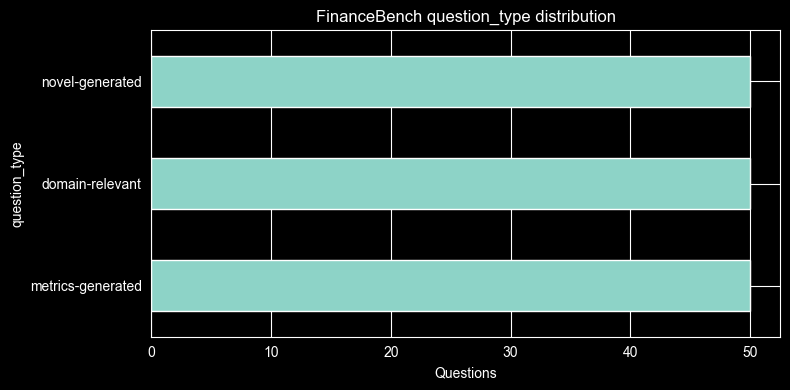

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
question_type_counts.sort_values().plot(kind="barh", ax=ax)
ax.set_title("FinanceBench question_type distribution")
ax.set_xlabel("Questions")
ax.set_ylabel("question_type")
plt.tight_layout()
plt.show()


## 5. Native `question_reasoning`


In [10]:
question_reasoning_counts = df["question_reasoning"].value_counts(dropna=False)
question_reasoning_counts


question_reasoning
None                                                                                            50
Numerical reasoning                                                                             43
Information extraction                                                                          31
Numerical reasoning OR Logical reasoning                                                         6
Logical reasoning (based on numerical reasoning)                                                 5
Logical reasoning (based on numerical reasoning) OR Logical reasoning                            5
Logical reasoning (based on numerical reasoning) OR Numerical reasoning OR Logical reasoning     4
Numerical reasoning OR information extraction                                                    4
Information extraction OR Logical reasoning OR                                                   1
Information extraction OR Logical reasoning                                               

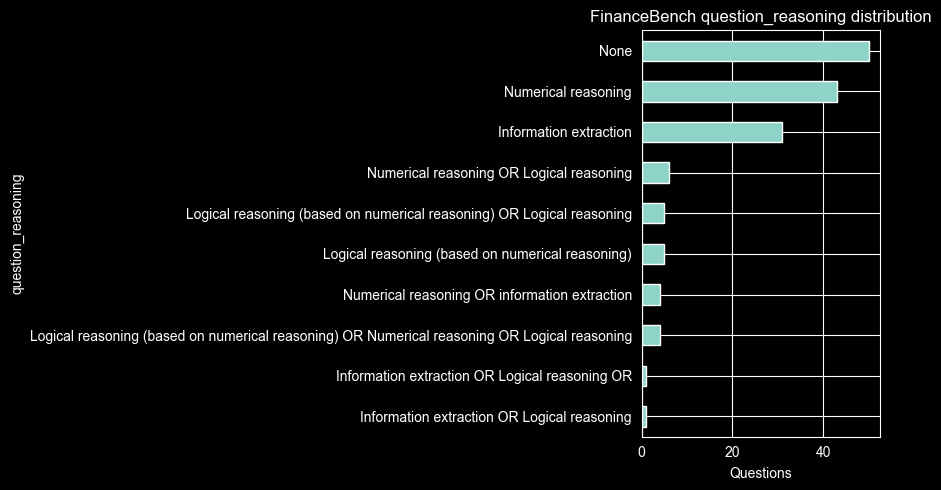

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
question_reasoning_counts.sort_values().plot(kind="barh", ax=ax)
ax.set_title("FinanceBench question_reasoning distribution")
ax.set_xlabel("Questions")
ax.set_ylabel("question_reasoning")
plt.tight_layout()
plt.show()


## 6. Companies and unique source documents


In [12]:
document_table = build_unique_document_table(df)
print("Unique companies:", df["company"].nunique(dropna=True))
print("Unique documents:", df["doc_name"].nunique(dropna=True))
document_table.head(10)


Unique companies: 32
Unique documents: 84


,doc_name,company,doc_type,doc_period,doc_link,gics_sector
0,3M_2018_10K,3M,10k,2018,https://investors.3m.com/financials/sec-filing...,Industrials
1,3M_2022_10K,3M,10k,2022,https://investors.3m.com/financials/sec-filing...,Industrials
2,3M_2023Q2_10Q,3M,10q,2023,https://investors.3m.com/financials/sec-filing...,Industrials
3,ACTIVISIONBLIZZARD_2019_10K,Activision Blizzard,10k,2019,https://investor.activision.com/static-files/3...,Communication Services
4,ADOBE_2015_10K,Adobe,10k,2015,https://www.adobe.com/pdf-page.html?pdfTarget=...,Information Technology
5,ADOBE_2016_10K,Adobe,10k,2016,https://www.adobe.com/pdf-page.html?pdfTarget=...,Information Technology
6,ADOBE_2017_10K,Adobe,10k,2017,https://www.adobe.com/pdf-page.html?pdfTarget=...,Information Technology
7,ADOBE_2022_10K,Adobe,10k,2022,https://www.adobe.com/pdf-page.html?pdfTarget=...,Information Technology
8,AES_2022_10K,AES Corporation,10k,2022,https://d18rn0p25nwr6d.cloudfront.net/CIK-0000...,Utilities
9,AMAZON_2017_10K,Amazon,10k,2017,https://d18rn0p25nwr6d.cloudfront.net/CIK-0001...,Consumer Discretionary


In [13]:
company_question_counts = df["company"].value_counts(dropna=False)
company_question_counts.head(20)


company
PepsiCo                 11
Amcor                    9
Johnson & Johnson        9
3M                       8
Boeing                   8
Best Buy                 8
AMD                      8
American Express         7
MGM Resorts              7
Pfizer                   6
Ulta Beauty              6
Verizon                  5
Adobe                    5
JPMorgan                 5
Corning                  4
CVS Health               4
Nike                     4
General Mills            4
American Water Works     3
Walmart                  3
Name: count, dtype: int64

## 7. Document types and periods


In [14]:
if "doc_type" in df.columns:
    display(df["doc_type"].value_counts(dropna=False))
else:
    print("doc_type is not available.")


doc_type
10k         112
10q          15
Earnings     14
8k            9
Name: count, dtype: int64

In [15]:
if "doc_period" in df.columns:
    print("Minimum document period:", df["doc_period"].min())
    print("Maximum document period:", df["doc_period"].max())
    display(df["doc_period"].value_counts(dropna=False).sort_index())
else:
    print("doc_period is not available.")


Minimum document period: 2015
Maximum document period: 2024


doc_period
2015     3
2016     3
2017     6
2018     7
2019     8
2020    10
2021    14
2022    61
2023    35
2024     3
Name: count, dtype: int64

## 8. Gold evidence counts

FinanceBench stores evidence as a list for each question. This will later provide ground truth for retrieval evaluation.


In [16]:
def evidence_count(value):
    return len(value) if isinstance(value, list) else 0

evidence_lengths = df["evidence"].apply(evidence_count)
evidence_lengths.describe()


count    150.000000
mean       1.260000
std        0.497376
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        3.000000
Name: evidence, dtype: float64

In [17]:
print("Evidence annotations per question:")
display(evidence_lengths.value_counts().sort_index())

nonempty = df.loc[evidence_lengths.gt(0), "evidence"]
if not nonempty.empty:
    print("\nFirst evidence object:")
    display(nonempty.iloc[0][0])


Evidence annotations per question:


evidence
1    115
2     31
3      4
Name: count, dtype: int64


First evidence object:


{'evidence_text': 'Table of Contents \n3M Company and Subsidiaries\nConsolidated Statement of Cash Flow s\nYears ended December 31\n \n(Millions)\n \n2018\n \n2017\n \n2016\n \nCash Flows from Operating Activities\n \n \n \n \n \n \n \nNet income including noncontrolling interest\n \n$\n5,363 \n$\n4,869 \n$\n5,058 \nAdjustments to reconcile net income including noncontrolling interest to net cash\nprovided by operating activities\n \n \n \n \n \n \n \nDepreciation and amortization\n \n \n1,488 \n \n1,544 \n \n1,474 \nCompany pension and postretirement contributions\n \n \n(370) \n \n(967) \n \n(383) \nCompany pension and postretirement expense\n \n \n410 \n \n334 \n \n250 \nStock-based compensation expense\n \n \n302 \n \n324 \n \n298 \nGain on sale of businesses\n \n \n(545) \n \n(586) \n \n(111) \nDeferred income taxes\n \n \n(57) \n \n107 \n \n 7 \nChanges in assets and liabilities\n \n \n \n \n \n \n \nAccounts receivable\n \n \n(305) \n \n(245) \n \n(313) \nInventories\n \n \n(509

## 9. Flatten evidence for inspection

Keep the benchmark's `evidence_page_num` as supplied. FinanceBench defines it as **zero-indexed**; Stage 4 should preserve this convention carefully.


In [18]:
evidence_rows = []

for _, row in df.iterrows():
    evidence_list = row["evidence"]
    if not isinstance(evidence_list, list):
        continue

    for evidence_index, item in enumerate(evidence_list):
        evidence_rows.append({
            "financebench_id": row["financebench_id"],
            "question_doc_name": row["doc_name"],
            "evidence_index": evidence_index,
            "evidence_doc_name": item.get("evidence_doc_name"),
            "evidence_page_num": item.get("evidence_page_num"),
            "evidence_text": item.get("evidence_text"),
            "evidence_text_full_page": item.get("evidence_text_full_page"),
        })

evidence_df = pd.DataFrame(evidence_rows)
print("Total evidence annotations:", len(evidence_df))
evidence_df.head()


Total evidence annotations: 189


,financebench_id,question_doc_name,evidence_index,evidence_doc_name,evidence_page_num,evidence_text,evidence_text_full_page
0,financebench_id_03029,3M_2018_10K,0,None,59,Table of Contents \n3M Company and Subsidiarie...,Table of Contents \n3M Company and Subsidiarie...
1,financebench_id_04672,3M_2018_10K,0,None,57,Table of Contents \n3M Company and Subsidiarie...,Table of Contents \n3M Company and Subsidiarie...
2,financebench_id_00499,3M_2022_10K,0,None,47,3M Company and Subsidiaries\nConsolidated Stat...,Table of Contents\n3M Company and Subsidiaries...
3,financebench_id_00499,3M_2022_10K,1,None,49,3M Company and Subsidiaries\nConsolidated Bala...,Table of Contents\n3M Company and Subsidiaries...
4,financebench_id_00499,3M_2022_10K,2,None,51,3M Company and Subsidiaries\nConsolidated Stat...,Table of Contents\n3M Company and Subsidiaries...


## 10. Evidence consistency checks


In [19]:
if evidence_df.empty:
    print("No evidence annotations were found.")
else:
    doc_mismatches = (
        evidence_df["question_doc_name"] != evidence_df["evidence_doc_name"]
    ).sum()
    print("Question doc_name / evidence_doc_name mismatches:", int(doc_mismatches))
    print("Missing evidence page numbers:", int(evidence_df["evidence_page_num"].isna().sum()))
    print("\nEvidence page number summary:")
    display(evidence_df["evidence_page_num"].describe())


Question doc_name / evidence_doc_name mismatches: 189
Missing evidence page numbers: 0

Evidence page number summary:


count    189.000000
mean      51.645503
std       43.577593
min        0.000000
25%       20.000000
50%       51.000000
75%       64.000000
max      303.000000
Name: evidence_page_num, dtype: float64

## 11. Question, answer and justification lengths


In [20]:
text_length_stats = pd.DataFrame({
    "question_chars": df["question"].fillna("").str.len(),
    "answer_chars": df["answer"].fillna("").str.len(),
    "justification_chars": df["justification"].fillna("").str.len(),
})
text_length_stats.describe()


,question_chars,answer_chars,justification_chars
count,150.000000,150.000000,150.000000
mean,161.093333,78.186667,150.453333
std,96.894902,96.555745,171.245363
min,44.000000,1.000000,0.000000
25%,80.000000,6.250000,0.000000
50%,137.500000,50.500000,100.500000
75%,210.750000,108.750000,219.500000
max,592.000000,609.000000,703.000000


## 12. Representative examples by native `question_type`


In [21]:
for category in df["question_type"].dropna().unique():
    print("=" * 100)
    print("question_type:", category)
    sample = df.loc[
        df["question_type"].eq(category),
        ["financebench_id", "question_reasoning", "question", "answer", "doc_name"],
    ].head(2)
    display(sample)


question_type: metrics-generated


,financebench_id,question_reasoning,question,answer,doc_name
0,financebench_id_03029,Information extraction,What is the FY2018 capital expenditure amount ...,$1577.00,3M_2018_10K
1,financebench_id_04672,Information extraction,Assume that you are a public equities analyst....,$8.70,3M_2018_10K


question_type: domain-relevant


,financebench_id,question_reasoning,question,answer,doc_name
2,financebench_id_00499,Logical reasoning (based on numerical reasoning),Is 3M a capital-intensive business based on FY...,"No, the company is managing its CAPEX and Fixe...",3M_2022_10K
3,financebench_id_01226,Logical reasoning (based on numerical reasonin...,What drove operating margin change as of FY202...,Operating Margin for 3M in FY2022 has decrease...,3M_2022_10K


question_type: novel-generated


,financebench_id,question_reasoning,question,answer,doc_name
4,financebench_id_01865,None,"If we exclude the impact of M&A, which segment...",The consumer segment shrunk by 0.9% organically.,3M_2022_10K
7,financebench_id_01858,None,Does 3M maintain a stable trend of dividend di...,"Yes, not only they distribute the dividends on...",3M_2023Q2_10Q


## 13. Representative examples by native `question_reasoning`


In [22]:
for reasoning in df["question_reasoning"].dropna().unique():
    print("=" * 100)
    print("question_reasoning:", reasoning)
    sample = df.loc[
        df["question_reasoning"].eq(reasoning),
        ["financebench_id", "question_type", "question", "answer"],
    ].head(1)
    display(sample)


question_reasoning: Information extraction


,financebench_id,question_type,question,answer
0,financebench_id_03029,metrics-generated,What is the FY2018 capital expenditure amount ...,$1577.00


question_reasoning: Logical reasoning (based on numerical reasoning)


,financebench_id,question_type,question,answer
2,financebench_id_00499,domain-relevant,Is 3M a capital-intensive business based on FY...,"No, the company is managing its CAPEX and Fixe..."


question_reasoning: Logical reasoning (based on numerical reasoning) OR Numerical reasoning OR Logical reasoning


...

,financebench_id,question_type,question,answer
16,financebench_id_00540,domain-relevant,Roughly how many times has AES Corporation sol...,AES has converted inventory 9.5 times in FY 2022.


question_reasoning: Information extraction OR Logical reasoning OR


,financebench_id,question_type,question,answer
25,financebench_id_01148,domain-relevant,What industry does AMCOR primarily operate in?,Amcor is a global leader in packaging producti...


question_reasoning: Information extraction OR Logical reasoning


,financebench_id,question_type,question,answer
63,financebench_id_01290,domain-relevant,Who are the primary customers of Boeing as of ...,Boeing's primary customers as of FY2022 are a ...


## 14. Future H1/H2 subgroup flags — not created yet

Later you may define transparent flags such as:

- `contains_numeric_reference`
- `contains_financial_metric`
- `requires_calculation`
- `requires_information_extraction`

Define the rule **before** looking at subgroup performance from P0–P3.


## 15. Write `dataset_summary.json` from measured values


In [23]:
summary = {
    "questions": int(len(df)),
    "unique_question_ids": int(df["financebench_id"].nunique(dropna=True)),
    "unique_documents": int(df["doc_name"].nunique(dropna=True)),
    "unique_companies": int(df["company"].nunique(dropna=True)),
    "question_types": {
        str(key): int(value) for key, value in question_type_counts.items()
    },
    "question_reasoning": {
        str(key): int(value) for key, value in question_reasoning_counts.items()
    },
    "document_types": (
        {str(key): int(value) for key, value in df["doc_type"].value_counts(dropna=False).items()}
        if "doc_type" in df.columns else {}
    ),
    "evidence": {
        "total_annotations": int(len(evidence_df)),
        "min_annotations_per_question": int(evidence_lengths.min()),
        "max_annotations_per_question": int(evidence_lengths.max()),
        "mean_annotations_per_question": float(evidence_lengths.mean()),
    },
    "integrity": integrity,
}

SUMMARY_PATH.parent.mkdir(parents=True, exist_ok=True)
with SUMMARY_PATH.open("w", encoding="utf-8") as handle:
    json.dump(summary, handle, indent=2, ensure_ascii=False)

print(json.dumps(summary, indent=2, ensure_ascii=False))
print("\nSaved:", SUMMARY_PATH)


{
  "questions": 150,
  "unique_question_ids": 150,
  "unique_documents": 84,
  "unique_companies": 32,
  "question_types": {
    "metrics-generated": 50,
    "domain-relevant": 50,
    "novel-generated": 50
  },
  "question_reasoning": {
    "None": 50,
    "Numerical reasoning": 43,
    "Information extraction": 31,
    "Numerical reasoning OR Logical reasoning": 6,
    "Logical reasoning (based on numerical reasoning)": 5,
    "Logical reasoning (based on numerical reasoning) OR Logical reasoning": 5,
    "Logical reasoning (based on numerical reasoning) OR Numerical reasoning OR Logical reasoning": 4,
    "Numerical reasoning OR information extraction": 4,
    "Information extraction OR Logical reasoning OR": 1,
    "Information extraction OR Logical reasoning": 1
  },
  "document_types": {
    "10k": 112,
    "10q": 15,
    "Earnings": 14,
    "8k": 9
  },
  "evidence": {
    "total_annotations": 189,
    "min_annotations_per_question": 1,
    "max_annotations_per_question": 3,
  

## Stage 2 stop condition

Before moving on, you should be able to explain:

1. every important FinanceBench column used by the project;
2. the three native `question_type` classes;
3. the native `question_reasoning` classes;
4. the measured number of companies and source documents;
5. the structure of each gold evidence object;
6. that `evidence_page_num` is zero-indexed;
7. why custom numeric/terminology labels have not yet been created.

Then run:

```bash
python scripts/download_documents.py
```
